<a href="https://colab.research.google.com/github/khanalfia05-sudo/bajajhfl-analysis/blob/main/Arima_dav_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance statsmodels matplotlib pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [12]:
data = yf.download("BAJAJFINSV.NS", period="1y")
data.head()

/tmp/ipykernel_177/2281719382.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BAJAJFINSV.NS", period="1y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BAJAJFINSV.NS,BAJAJFINSV.NS,BAJAJFINSV.NS,BAJAJFINSV.NS,BAJAJFINSV.NS
Date,,,,,
2025-03-17,1870.688599,1879.984119,1796.274901,1819.113750,6994837
2025-03-18,1870.688599,1870.688599,1870.688599,1870.688599,0
2025-03-19,1841.352905,1863.492144,1839.104001,1854.096697,2411880
2025-03-20,1850.948120,1854.096610,1813.216504,1841.352820,2306910
2025-03-21,1846.350464,1879.084516,1824.111299,1877.085490,3537391


In [4]:
data.to_csv("bajajhfl.csv")

In [5]:
data.reset_index(inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [6]:
print(data.isnull().sum())

Price      Ticker      
Adj Close  BAJAJHFL.CSV    0
Close      BAJAJHFL.CSV    0
High       BAJAJHFL.CSV    0
Low        BAJAJHFL.CSV    0
Open       BAJAJHFL.CSV    0
Volume     BAJAJHFL.CSV    0
dtype: int64


In [7]:
data.fillna(method='ffill', inplace=True)


/tmp/ipykernel_177/1984096990.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


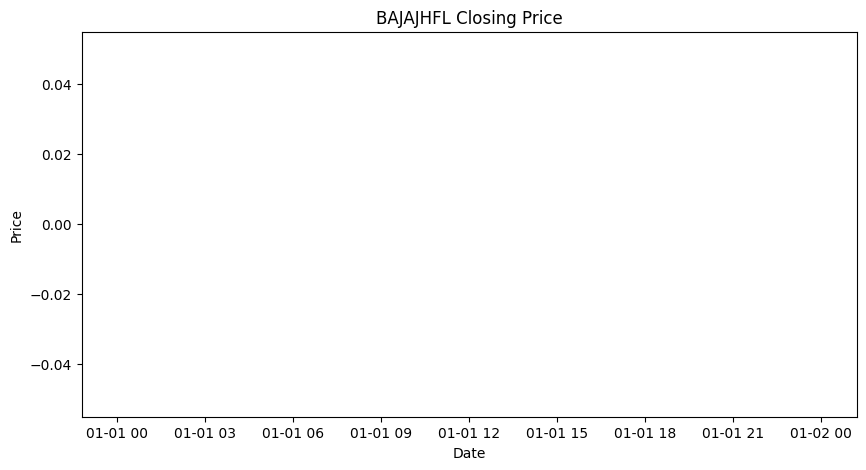

In [8]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("BAJAJHFL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller

# Ensure data exists
print(data.head())

# Use Close column
series = data['Close'].dropna()

result = adfuller(series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

Price              Close          High           Low          Open  \
Ticker     BAJAJFINSV.NS BAJAJFINSV.NS BAJAJFINSV.NS BAJAJFINSV.NS   
Date                                                                 
2025-03-17   1870.688599   1879.984119   1796.274901   1819.113750   
2025-03-18   1870.688599   1870.688599   1870.688599   1870.688599   
2025-03-19   1841.352905   1863.492144   1839.104001   1854.096697   
2025-03-20   1850.948120   1854.096610   1813.216504   1841.352820   
2025-03-21   1846.350464   1879.084516   1824.111299   1877.085490   

Price             Volume  
Ticker     BAJAJFINSV.NS  
Date                      
2025-03-17       6994837  
2025-03-18             0  
2025-03-19       2411880  
2025-03-20       2306910  
2025-03-21       3537391  
ADF Statistic: -2.877995375737414
p-value: 0.04796732525225942


In [11]:
data['Close_diff'] = data['Close'].diff()
data.dropna(inplace=True)

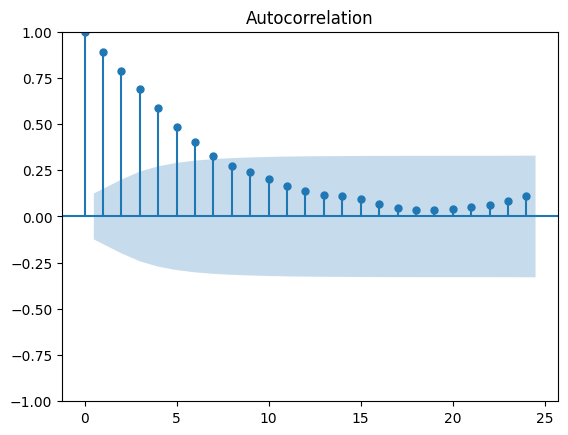

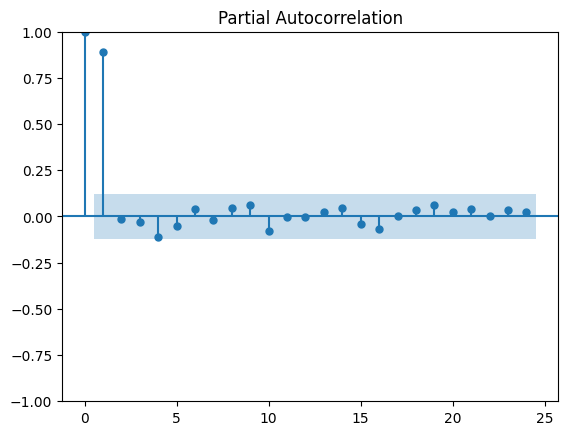

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(data['Close'])
plot_pacf(data['Close'])
plt.show()

In [14]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data['Close'], order=(1,1,1))  # you can adjust
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          BAJAJFINSV.NS   No. Observations:                  249
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1182.310
Date:                Tue, 17 Mar 2026   AIC                           2370.621
Time:                        15:03:18   BIC                           2381.161
Sample:                             0   HQIC                          2374.864
                                - 249                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2770      0.662      0.418      0.676      -1.021       1.575
ma.L1         -0.3531      0.637     -0.555      0.579      -1.601       0.895
sigma2       809.8584     50.465     16.048      0.0

In [15]:
forecast = model_fit.forecast(steps=30)
print(forecast)

249    1774.148679
250    1773.995968
251    1773.953665
252    1773.941947
253    1773.938700
254    1773.937801
255    1773.937552
256    1773.937483
257    1773.937464
258    1773.937458
259    1773.937457
260    1773.937457
261    1773.937457
262    1773.937456
263    1773.937456
264    1773.937456
265    1773.937456
266    1773.937456
267    1773.937456
268    1773.937456
269    1773.937456
270    1773.937456
271    1773.937456
272    1773.937456
273    1773.937456
274    1773.937456
275    1773.937456
276    1773.937456
277    1773.937456
278    1773.937456
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


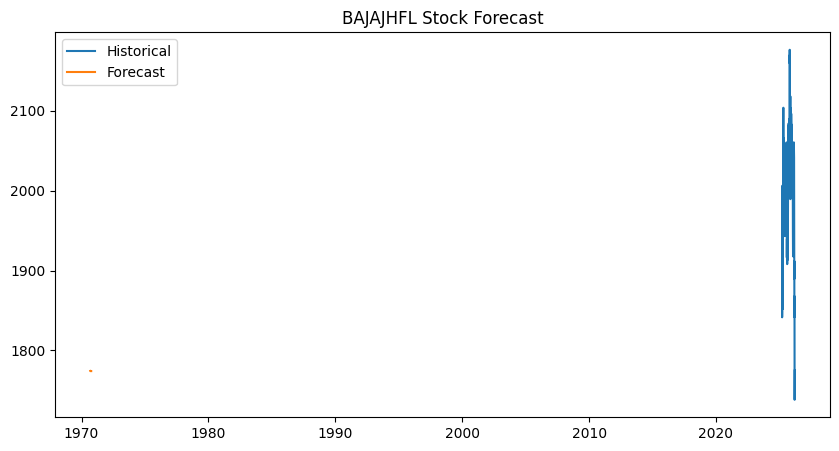

In [16]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Historical')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("BAJAJHFL Stock Forecast")
plt.show()